In [1]:
import numpy as np
import matplotlib.pyplot as plt

In [ ]:
def generate_modulation(t, edges):
    y = np.zeros_like(t)
    for on, off in zip(edges[0::2], edges[1::2]):
        y[(t >= on) & (t < off)] = 1
    return t, y



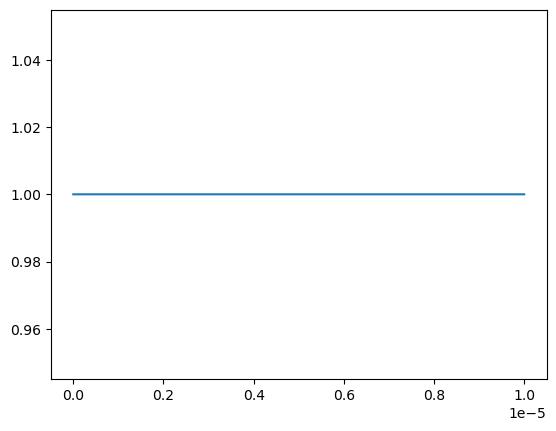

In [8]:
MAX_SAMPLE_RATE = 250e6
duration = 10e-6
edges = [0e-6, 10e-6]

num_samples = int(MAX_SAMPLE_RATE * duration)
t = np.arange(num_samples) / MAX_SAMPLE_RATE
_, mod = generate_modulation(t, edges)

fig, ax = plt.subplots()
ax.plot(t, mod)

300


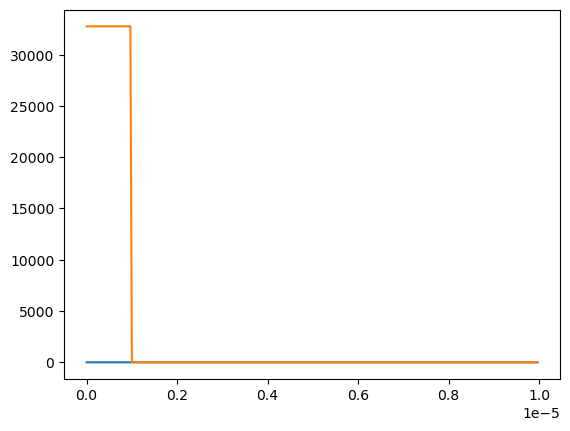

In [2]:
def load_csv(csv_file):
    data = np.genfromtxt(csv_file, delimiter=",", skip_header=1)
    t = np.asarray(data[:, 0], dtype=np.float32)
    ch1 = np.asarray(data[:, 1], dtype=np.float32)
    # ch2 = np.asarray(data[:, 2], dtype=np.float32)
    return t, ch1

np.uint16(1)
t, ch1 = load_csv("./waveforms/sdg1062x.csv")
fig, ax = plt.subplots()
ax.plot(t, ch1)
print(len(ch1))
waveform = ch1 * 32767
# -32768~32767

ax.plot(t, waveform)




False
-2494497.040649414
1836296.4187011719


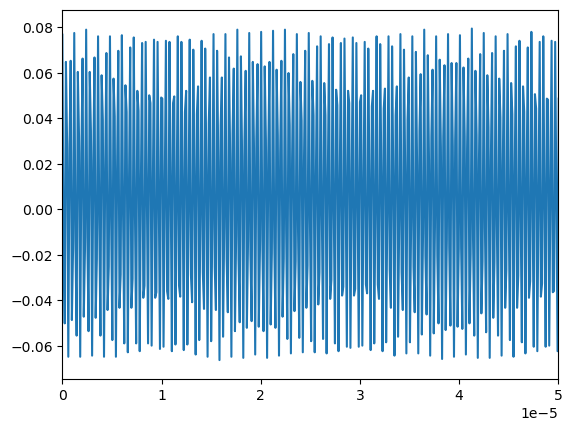

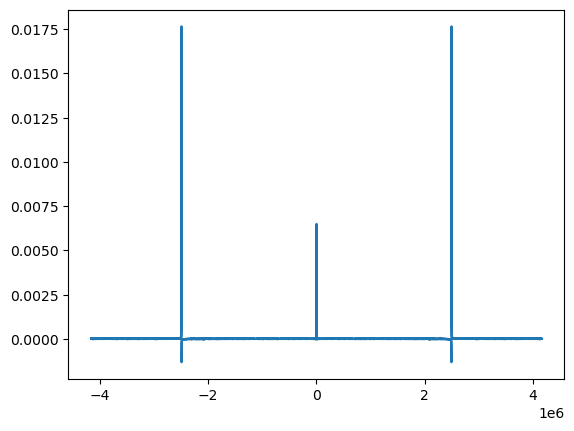

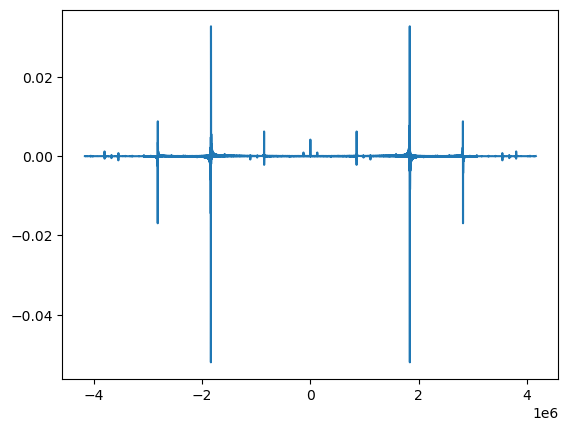

In [ ]:
def compute_fft(t, y):
    dt = t[1] - t[0]
    N = len(y)
    Y = np.fft.fft(y)
    f = np.fft.fftfreq(N, d=dt)

    Y = np.fft.fftshift(Y)
    f = np.fft.fftshift(f)

    return f, Y / len(y)



fig, ax = plt.subplots()
t, ch1 = load_csv("D:/data/WFMNEW03.CSV")
ax.plot(t, ch1)
t2, ch12 = load_csv("D:/data/WFMNEW07.CSV")
# ax.plot(t2, ch12)
t3, ch13 = load_csv("D:/data/WFMNEW09.CSV")
# ax.plot(t3, ch13)

print(np.array_equal(ch1, ch12))

ax.set_xlim([0, 5e-5])

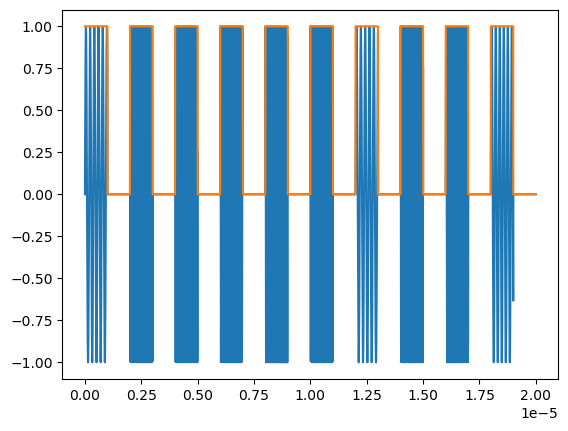

In [ ]:
def load_csv_two_channels(csv_file):
    data = np.genfromtxt(csv_file, delimiter=",", skip_header=1)
    t = np.asarray(data[:, 0], dtype=np.float32)
    ch1 = np.asarray(data[:, 1], dtype=np.float32)
    ch2 = np.asarray(data[:, 2], dtype=np.float32)
    return t, ch1, ch2

t, ch1, ch2 = load_csv_two_channels("./waveforms/test_scope.csv")
fig, ax = plt.subplots()
ax.plot(t, ch1)
ax.plot(t, ch2)

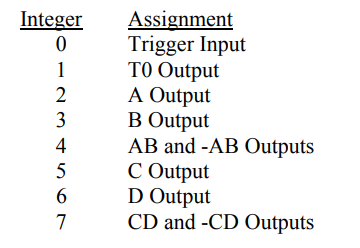

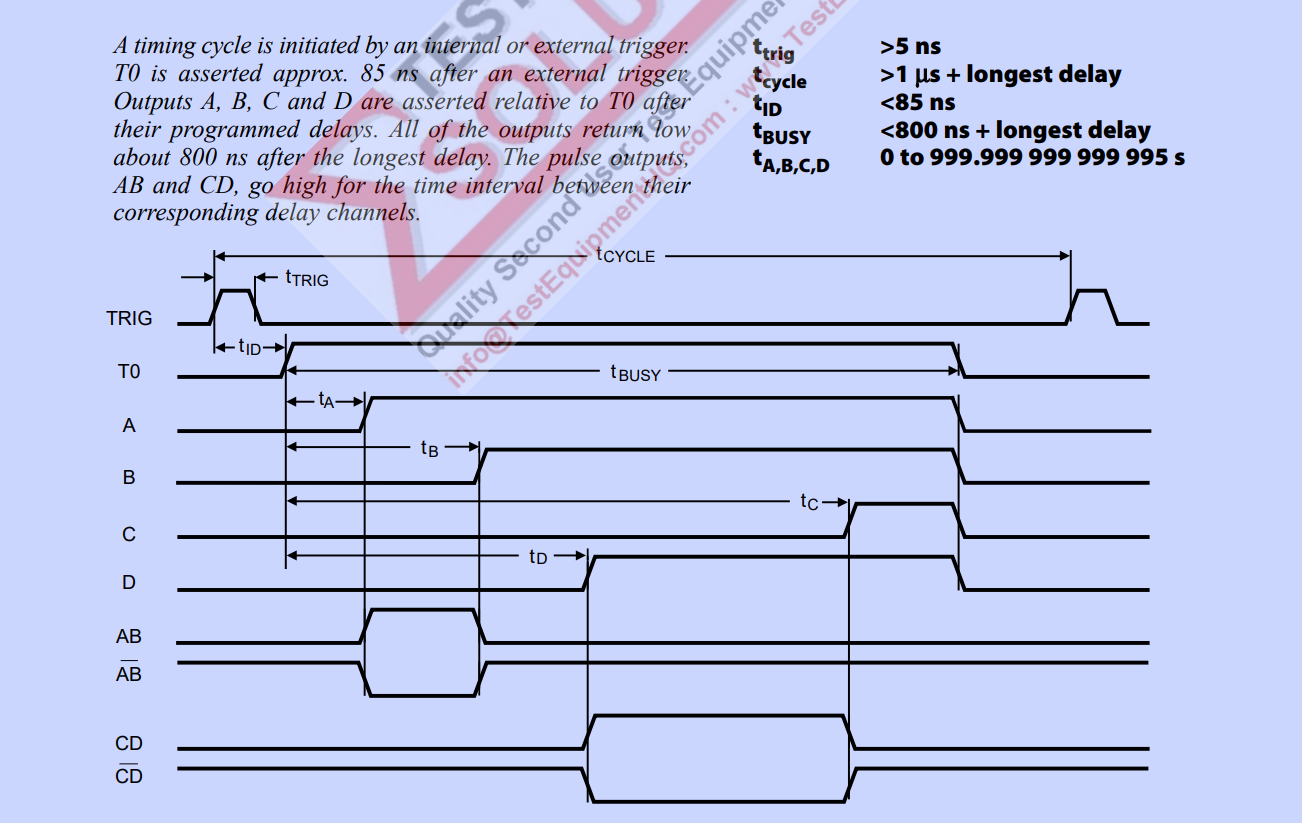

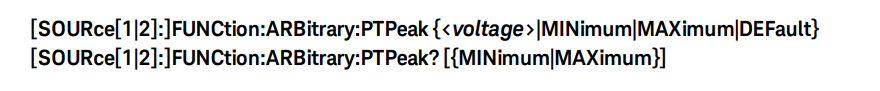

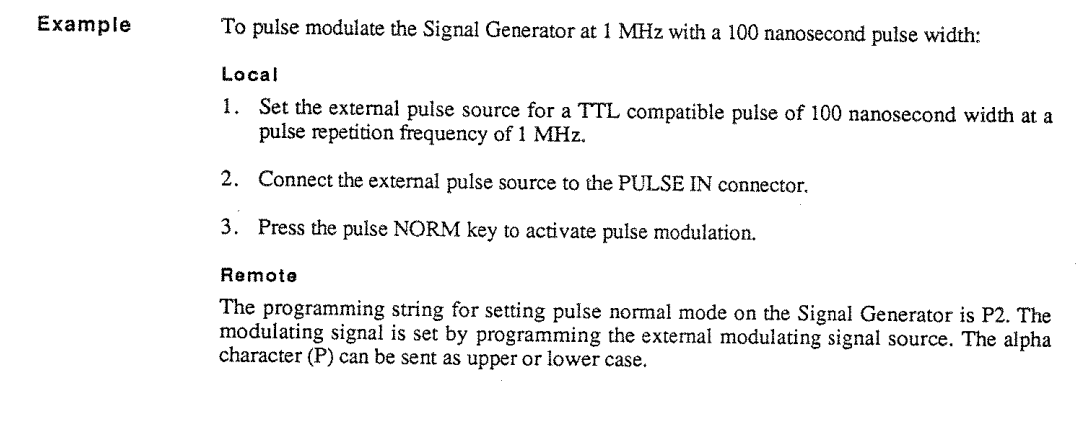